# Compare the different implementations of the same model

Import libraries

In [44]:
%load_ext autoreload
%autoreload 2

import sys
import warnings

sys.path.append('..')
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Import local moduls

In [45]:
import run
import params as params

In [46]:
data = run.run_original()

*** Reward Estimation ***
** Baseline **
    State 1: 10.0    (Real: 10)
    State 2: 0.999    (Real: 1)
** Reward Revaluation **
    State 1: 4.393    (Real: 1)
    State 2: 6.93    (Real: 10)
** Transition Revaluation **
    State 1: 8.099    (Real: 1)
    State 2: 3.2120000000000006    (Real: 10)
*** Reward Revaluation (scaled) ***
  Mean = 0.5199
  SEM  = 0.0154

Transition revaluation:
  Mean = 0.1854
  SEM  = 0.0158


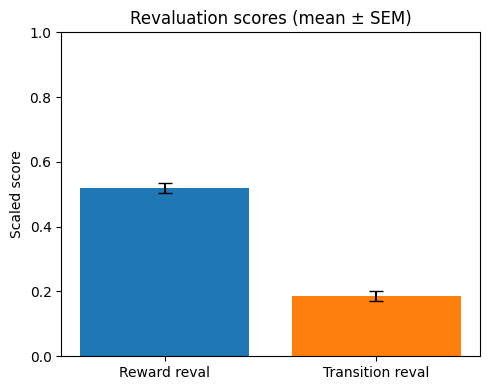

In [47]:
# Model data
reval_scores_reward = np.array(data['reval_scores_reward'])
reval_scores_transition = np.array(data['reval_scores_transition'])

# get scaling factor: scale reward_reval to .5199
scaling_factor = .5199 / reval_scores_reward.mean()

# scale data
rs_reward_scaled = reval_scores_reward * scaling_factor
rs_transition_scaled = reval_scores_transition * scaling_factor

# Means
means = [
    rs_reward_scaled.mean(),
    rs_transition_scaled.mean()
]

# SEMs
sems = [
    rs_reward_scaled.std(ddof=1) / np.sqrt(len(rs_reward_scaled)),
    rs_transition_scaled.std(ddof=1) / np.sqrt(len(rs_transition_scaled))
]

# Estimated Rewards
er_baseline_1 = np.array(data['estimated_reward_state_1_baseline']).mean()
er_baseline_2 = np.array(data['estimated_reward_state_2_baseline']).mean()
er_reward_reval_1 = np.array(data['estimated_reward_state_1_reward_reval']).mean()
er_reward_reval_2 = np.array(data['estimated_reward_state_2_reward_reval']).mean()
er_transition_reval_1 = np.array(data['estimated_reward_state_1_transition_reval']).mean()
er_transition_reval_2 = np.array(data['estimated_reward_state_2_transition_reval']).mean()

print("*** Reward Estimation ***")
print("** Baseline **")
print(f"    State 1: {er_baseline_1}    (Real: {params.REWARD_BASELINE_1})")
print(f"    State 2: {er_baseline_2}    (Real: {params.REWARD_BASELINE_2})")
print('** Reward Revaluation **')
print(f"    State 1: {er_reward_reval_1}    (Real: {params.REWARD_BASELINE_2})")
print(f"    State 2: {er_reward_reval_2}    (Real: {params.REWARD_BASELINE_1})")
print('** Transition Revaluation **')
print(f"    State 1: {er_transition_reval_1}    (Real: {params.REWARD_BASELINE_2})")
print(f"    State 2: {er_transition_reval_2}    (Real: {params.REWARD_BASELINE_1})")

print("*** Reward Revaluation (scaled) ***")
print(f"  Mean = {means[0]:.4f}")
print(f"  SEM  = {sems[0]:.4f}")

print("\nTransition revaluation:")
print(f"  Mean = {means[1]:.4f}")
print(f"  SEM  = {sems[1]:.4f}")

# Plot
plt.figure(figsize=(5, 4))
x = np.arange(2)
labels = ["Reward reval", "Transition reval"]

plt.bar(x, means, yerr=sems, capsize=5,
        color=["tab:blue", "tab:orange"])

plt.xticks(x, labels)
plt.ylabel("Scaled score")
plt.ylim(0, 1)

plt.title("Revaluation scores (mean ± SEM)")
plt.tight_layout()
plt.show()

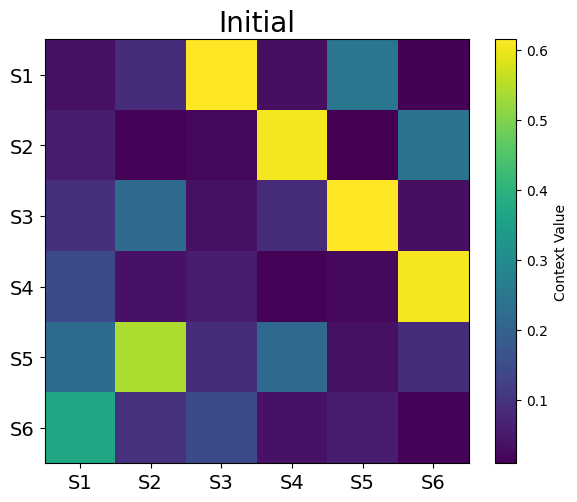

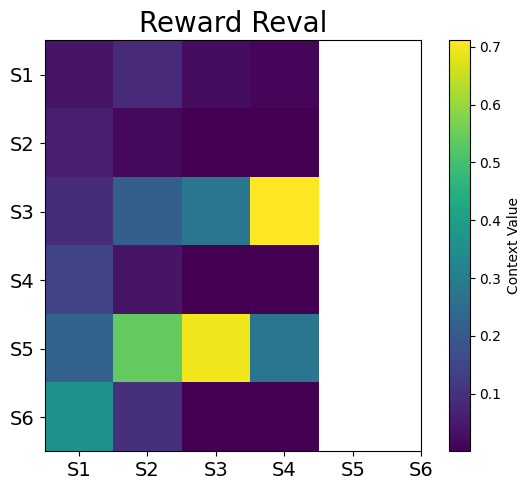

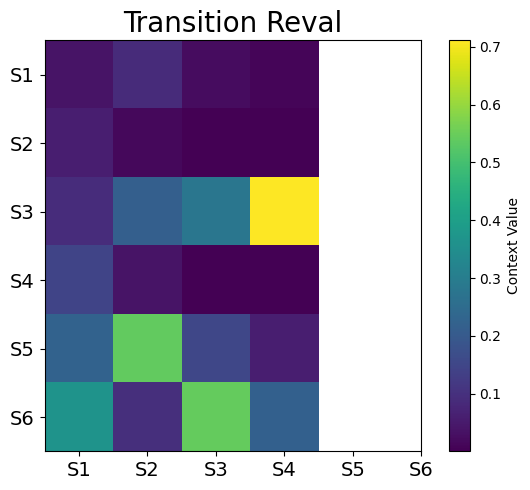

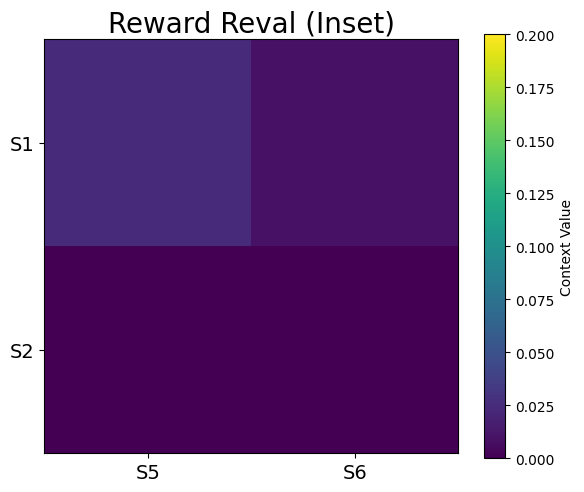

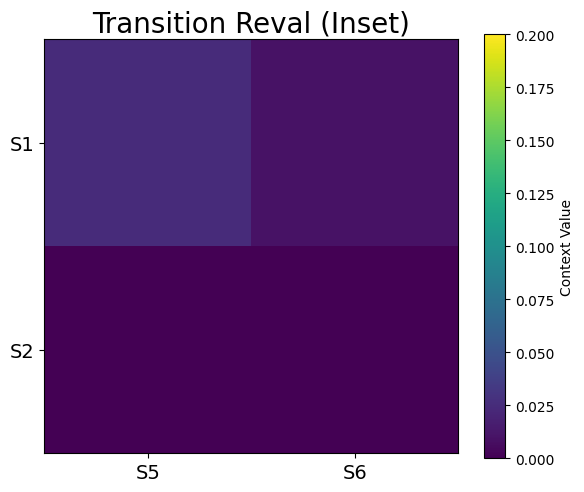

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial

from run import gen_trials
import model_python
import params

# ============================================================
# 1. Generate sample trials (single participant for plotting)
# ============================================================

trials = gen_trials(
    num_seqs_baseline=20,
    num_seqs_revaluation=20,
    num_trials=1
)

trial = trials[0]

baseline_trials                = trial['baseline_trials']
baseline_rewards               = trial['baseline_rewards']
reward_revaluation_trials      = trial['reward_revaluation_trials']
reward_revaluation_rewards     = trial['reward_revaluation_rewards']
transition_revaluation_trials  = trial['transition_revaluation_trials']
transition_revaluation_rewards = trial['transition_revaluation_rewards']
time_sequence                  = trial['time_sequence']


# ============================================================
# 2. Prepare the new memory generator
# ============================================================

_gen_memories = partial(
    model_python.gen_memories,
    state_integration_rate=params.STATE_INTEGRATION_RATE,
    context_d=params.STATE_SIZE
)


# ============================================================
# 3. Generate memories for all phases
# ============================================================

memories_baseline = _gen_memories(
    visited_states=baseline_trials,
    rewards=baseline_rewards,
    time_sequence=time_sequence[:len(baseline_trials)]
)

memories_reward_reval = _gen_memories(
    visited_states=reward_revaluation_trials,
    rewards=reward_revaluation_rewards,
    time_sequence=time_sequence
)

memories_transition_reval = _gen_memories(
    visited_states=transition_revaluation_trials,
    rewards=transition_revaluation_rewards,
    time_sequence=time_sequence
)


# ============================================================
# 4. Average memories by state (same logic as before)
# ============================================================

memory_sets = [
    memories_baseline,
    memories_reward_reval,
    memories_transition_reval
]

memory_averages = []

for memories in memory_sets:

    # slice 60:70 if long enough
    if len(memories[0]) > 60:
        states_vecs = memories[0][60:70]
        contexts    = memories[1][60:70]
    else:
        states_vecs = memories[0][:60]
        contexts    = memories[1][:60]

    # convert state vectors → discrete indices
    states = states_vecs.argmax(-1).numpy()

    df = pd.DataFrame(
        np.concatenate([contexts.numpy(), states[:, None]], axis=-1)
    )

    df.columns = [
        'Context 0','Context 1','Context 2','Context 3',
        'Context 4','Context 5','Context 6','State'
    ]

    memory_averages.append(
        df.groupby('State', as_index=False).mean()
    )

average_initial_contexts, average_reward_reval_contexts, average_transition_reval_contexts = memory_averages


# ============================================================
# 5. Build matrices for heatmaps
# ============================================================

initial_matrix = average_initial_contexts.values[:, 2:].T

reward_matrix = np.concatenate(
    [
        initial_matrix[:, :2],                           # baseline context for s1-s2
        average_reward_reval_contexts.values[:, 2:].T    # reval contexts for s3-s6
    ],
    axis=1
)

transition_matrix = np.concatenate(
    [
        initial_matrix[:, :2],
        average_transition_reval_contexts.values[:, 2:].T
    ],
    axis=1
)


# ============================================================
# 6. Matplotlib Heatmap Function
# ============================================================

def plot_heatmap(matrix, title, xticks, yticks, vmin=None, vmax=None):
    plt.figure(figsize=(6, 5))
    plt.imshow(matrix, cmap="viridis", aspect="equal", vmin=vmin, vmax=vmax)
    plt.colorbar(label="Context Value")

    plt.xticks(range(len(xticks)), xticks, fontsize=14)
    plt.yticks(range(len(yticks)), yticks, fontsize=14)

    plt.title(title, fontsize=20)
    plt.tight_layout()
    plt.show()


# ============================================================
# 7. Full Heatmaps (Initial / Reward / Transition)
# ============================================================

xticks = [f"S{i}" for i in range(1, 7)]
yticks = [f"S{i}" for i in range(1, 7)]

plot_heatmap(initial_matrix,        "Initial",         xticks, yticks)
plot_heatmap(reward_matrix,         "Reward Reval",    xticks, yticks)
plot_heatmap(transition_matrix,     "Transition Reval",xticks, yticks)


# ============================================================
# 8. Inset Heatmaps (top-left 2×2)
# ============================================================

inset_xticks = ["S5", "S6"]
inset_yticks = ["S1", "S2"]

plot_heatmap(
    reward_matrix[:2, -2:],
    "Reward Reval (Inset)",
    inset_xticks, inset_yticks,
    vmin=0, vmax=0.2
)

plot_heatmap(
    transition_matrix[:2, -2:],
    "Transition Reval (Inset)",
    inset_xticks, inset_yticks,
    vmin=0, vmax=0.2
)


In [ ]:

plot_data = pd.DataFrame(revaluation_scores[:,:2],columns=['Reward<br>Revaluation','Transition<br>Revaluation']).melt(var_name='Condition',value_name='Revaluation Score')
scaling_factor = .5199/revaluation_scores[:,0].mean() # Scale revaluation scores to match mean of behavioral data
t_test_results = pg.pairwise_tests(plot_data,between='Condition',dv='Revaluation Score')

plot_data['Revaluation Score'] *= scaling_factor
plot_data = plot_data.groupby(['Condition']).agg(**{'Revaluation Score': ('Revaluation Score','mean'), 'error': ('Revaluation Score','sem')}).reset_index()
fig = px.bar(plot_data,range_y=[0,1],x='Condition',y='Revaluation Score',color='Condition',error_y='error',
             color_discrete_sequence=['#0099C6','#FF9900'],title='Model Performance')
fig.update_layout(showlegend=False)
fig.show()